### Bulk density of states



The density of states refers to the number of electronic states in a particular energy range.

The solution to Eq. eqref:eq:KS yields a set of Kohn-Sham (K-S) orbitals and an
associated set of eigenvalues that correspond to the energies of these
orbitals, neither of which have any known directly observable meaning
cite:RevModPhys.71.1253.  The sum of the squared K-S orbitals,
however, is equal to the electron density (Eq. \eqref{eq:density}),
and the sum of the eigenvalues is a significant part of the total
energy (Eq.  \eqref{eq:dftEnergy}). Thus, it seems reasonable to
suppose these quantities have other significant relationships to
physical observables. Perdew et al. showed that the highest occupied
eigenvalue is equal to the ionization energy of a system within an
exact density functional theory cite:perdew1982:elect-kohn-sham, but
their interpretation has been vigorously debated in the literature
cite:kleinman1997:signif-kohn-sham,perdew1997,kleinman1997:reply-commen-kohn-sham,
and is only true for the exact exchange/correlation functional, not
the approximate ones used in practice cite:koch2001.
Stowasser and Hoffmann discussed an approach to using the K-S orbitals
in more traditional molecular orbital interpretations, but the results
were primarily qualitative cite:stowasser1999:what-kohn-sham. More
recently, a DFT analog of Koopmans' theorem has been developed that
formally identifies the eigenvalues with vertical ionization
potentials, which can be measured with photoelectron spectroscopy
cite:gritsenko2002.

Despite the arguments against ascribing physical meaning to the K-S
orbitals and eigenvalues, it has become fairly standard, especially
for solids, to use them to calculate the density of states (DOS)
cite:jones1989 [Sec.  VI.  B].  This has been found to yield
reasonable results for the valence bands in metals, but poor results
for tightly bound orbitals and band gaps
cite:perdew1982:elect-kohn-sham. A highly technical discussion of
this issue can be found in Ref. citealp:perdew1981:self.  The
density of states can be calculated by a sum over the k-points
cite:seitsonen2000:phd:

\begin{equation}
\rho(\epsilon)=\sum_\mathbf{\mathrm{k}} \omega_\mathbf{\mathrm{k}} \sum_i \beta(\epsilon -\epsilon_{i\mathbf{\mathrm{k}}})
\end{equation}

where $\omega_\mathbf{\mathrm{k}}$ is the weight associated with the
k-point, and $\beta$ is a broadening function, typically a gaussian
function, to account for the finite number of k-points used in the
calculations. The amount of broadening is arbitrary, and should tend
to zero as the number of k-points approaches infinity.



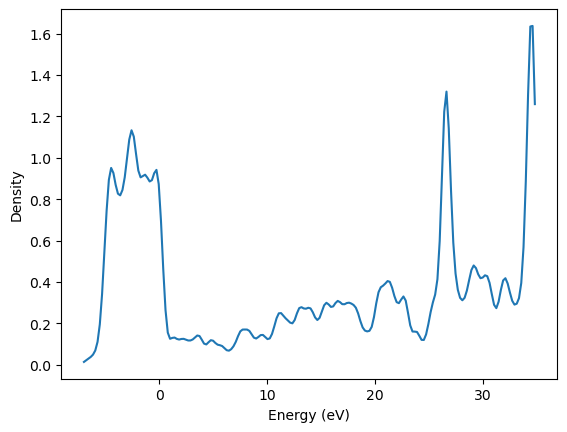

In [1]:
from ase import Atoms, Atom
from vasp import Vasp
import numpy as np

npoints = 200
width = 0.5

def gaussian(energies, eik):
    x = ((energies - eik) / width)
    return np.exp(-x**2) / np.sqrt(np.pi) / width

# Set up Pd bulk structure
a = 3.9  # approximate lattice constant
b = a / 2.
bulk = Atoms([Atom('Pd', (0.0, 0.0, 0.0))],
             cell=[(0, b, b),
                   (b, 0, b),
                   (b, b, 0)])

calc = Vasp(label='bulk/pd-dos',
            encut=300,
            xc='PBE',
            kpts=(8, 8, 8),
            atoms=bulk)

calc.calculate()

# kpt weights
wk = calc.get_k_point_weights()

# for each k-point there are a series of eigenvalues
# here we get all the eigenvalues for each k-point
e_kn = []
for i, k in enumerate(wk):
    e_kn.append(calc.get_eigenvalues(kpt=i))

e_kn = np.array(e_kn) - calc.get_fermi_level()

# these are the energies we want to evaluate the dos at
energies = np.linspace(e_kn.min(), e_kn.max(), npoints)

# this is where we build up the dos
dos = np.zeros(npoints)

for j in range(npoints):
    for k in range(len(wk)): # loop over all kpoints
        for i in range(len(e_kn[k])): # loop over eigenvalues in each k
            dos[j] += wk[k] * gaussian(energies[j], e_kn[k][i])

import matplotlib.pyplot as plt
plt.plot(energies, dos)
plt.xlabel('Energy (eV)')
plt.ylabel('Density');



Here is a more convenient way to compute the DOS using mod:ase.dft.



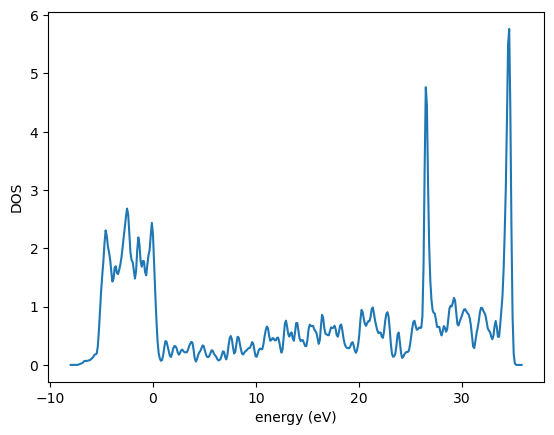

In [2]:
from vasp import Vasp
import matplotlib.pyplot as plt
from ase.dft import DOS

calc = Vasp(label='bulk/pd-dos')
dos = DOS(calc, width=0.2)
d = dos.get_dos()
e = dos.get_energies()

import pylab as plt
plt.plot(e, d)
plt.xlabel('energy (eV)')
plt.ylabel('DOS');


This DOS looks roughly like you would expect. The peak between -5 to 0 eV is the Pd d-band.

The VASP manual [recommends](http://cms.mpi.univie.ac.at/vasp/guide/node124.html#SECTION000933000000000000000) a final run be made with ISMEAR=-5, which uses the tetrahedron method with Bl\\"ochl corrections.



In [3]:
from vasp import Vasp
from ase.dft import DOS
calc = Vasp(label='bulk/pd-dos').clone('bulk/pd-dos-ismear-5')

bulk = calc.load_atoms()
calc.set(ismear=-5)
calc.calculate()

bulk.get_potential_energy()
dos = DOS(calc, width=0.2)
d = dos.get_dos()
e = dos.get_energies()

import pylab as plt
plt.plot(e, d)
plt.xlabel('energy [eV]')
plt.ylabel('DOS')


FileNotFoundError: No POSCAR/CONTCAR in /home/jovyan/dft-book/notebooks/04-bulk-systems/bulk/pd-dos-ismear-5

This not notably different to me.

We can test for convergence of the DOS. The k-points are most important.



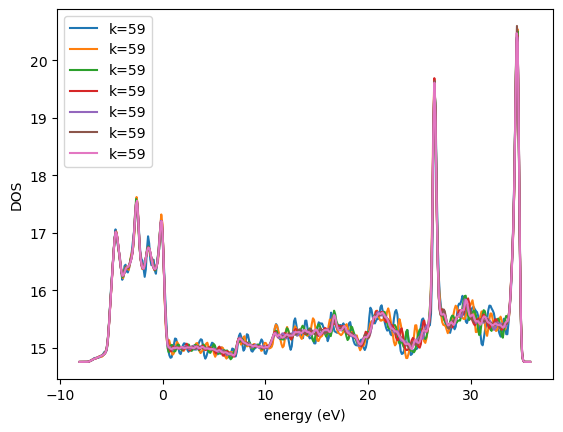

In [4]:
from ase import Atoms, Atom
from vasp import Vasp

import matplotlib.pyplot as plt
import numpy as np
from ase.dft import DOS

a = 3.9  # approximate lattice constant
b = a / 2.
bulk = Atoms([Atom('Pd', (0.0, 0.0, 0.0))],
             cell=[(0, b, b),
                   (b, 0, b),
                   (b, b, 0)])

kpts = [8, 10, 12, 14, 16, 18, 20]

calcs = [Vasp(label=f'bulk/pd-dos-k{k}-ismear-5',
              encut=300,
              xc='PBE',
              kpts=(k, k, k),
              atoms=bulk) for k in kpts]



for calc in calcs:
    # this runs the calculation
    if calc.potential_energy is not None:
        dos = DOS(calc, width=0.2)
        d = dos.get_dos() + k / 4.0
        e = dos.get_energies()

        plt.plot(e, d, label=f'k={k}')
    else:
        pass
plt.xlabel('energy (eV)')
plt.ylabel('DOS')
plt.legend()

    got here
    <ase.dft.dos.DOS instance at 0xec2d710>



In [5]:
from vasp import Vasp
from ase.dft import DOS

calc = Vasp(label='bulk/pd-dos-k20-ismear-5')
print(DOS(calc, width=0.2))